In [26]:
import torch
from torch import nn
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import wandb
import os
import yaml
import random
import csv

from model_v2 import TransformerBasedRegressor
from training_module import TrainEvaluateModel
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from loss import hurdle_nll_loss

import pandas as pd
import numpy as np
import torch
from pathlib import Path
import re
from torch.utils.data import Dataset
import random
import time
from scipy.stats import norm
import seaborn as sns
import pandas as pd
from matplotlib.ticker import ScalarFormatter, NullFormatter
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
config = {
    "d_model": 256,
    "d_out": 256,
    "drop_rate": 0.2,
    "context_length": 162,
    "num_layers": 3,
    "epochs": 400,
    "model_name": "scattering_regression_v2_1.pth",
    "architecture": "MultimodalTransformerLogNormal",
    "learning_rate": 0.0001,
    "weight_decay": 0.09,
    "nhead": 4,
    "batch_size": 32
}

In [ ]:
analysis_dir = "npy_files"

In [4]:
# Define transformation
transforms_train = v2.Compose([
    v2.Lambda(lambda x: (x - x.min()) / (x.max() - x.min())),
    v2.Lambda(lambda x: torch.roll(x, shifts=random.randint(-60, 10), dims=-1))
])
# Define transformation
transforms_test = v2.Compose([
    v2.Lambda(lambda x: (x - x.min()) / (x.max() - x.min())),
])

In [5]:
class CustomDataset(Dataset):
    def __init__(self, image_dir_path, transform=None):
        self.img_dir = Path(image_dir_path)
        self.transform = transform

        self.img_files = list(self.img_dir.glob("*.npy"))

    def __len__(self):
        return len(self.img_files)

    
    def __getitem__(self, idx):
        img_path = self.img_files[idx]

        file_number = int(re.split(r"[_.]", img_path.name)[2])

        # Load dynamic spectrum
        spectrum = np.load(img_path)
        timeseries = spectrum.mean(axis=0)

        # Convert to torch tensors
        spectrum = torch.tensor(spectrum, dtype=torch.float32).unsqueeze(0)
        timeseries = torch.tensor(timeseries, dtype=torch.float32).unsqueeze(0)
        
        if self.transform:
            spectrum = self.transform(spectrum)
            timeseries = self.transform(timeseries)


        return spectrum, timeseries, file_number


In [6]:
model = TransformerBasedRegressor(cfg=config)

In [ ]:
model.load_state_dict(torch.load("trained_models/scattering_regression_v2_1.pth", weights_only=True))

<All keys matched successfully>

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [10]:
analysis_dl = DataLoader(CustomDataset(analysis_dir, transforms_test), batch_size=1)

In [11]:
def predict_scattering_timescale(model, *inputs, device):
    model.to(device)
    img = inputs[0].to(device)
    ts = inputs[1].to(device)
    model.eval()
    with torch.inference_mode():
        p0, mu, sigma = model(img, ts)

    # Expected τ (mixture mean)
    tau_mean_pos = torch.exp(mu + 0.5 * sigma**2)
    tau_pred = (1 - p0) * tau_mean_pos

    # Conditional and 95% CI (if τ > 0)
    tau_med = torch.exp(mu)
    ci95_lower = torch.exp(mu - 1.96 * sigma)
    ci95_upper = torch.exp(mu + 1.96 * sigma)
    ci95 = torch.cat([ci95_lower, ci95_upper], dim=-1)

    return tau_med, p0, ci95, sigma

In [12]:
file_numbers = []
prediction = []
scattering_probability = []
y_error_lower = []
y_error_upper = []
sigmas = []

for img, ts, file_number in analysis_dl:
    tau_med, p0, ci95, sigma = predict_scattering_timescale(model, *[img, ts], device=device)
    Med = tau_med.item() / 1.15
    error_lower = (tau_med.item()/ 1.15) - (ci95.tolist()[0][0] / 1.15)
    error_upper = (ci95.tolist()[0][1] / 1.15) - (tau_med.item()/ 1.15)
    prediction.append(Med)
    scattering_probability.append(1-p0.item())
    y_error_lower.append(error_lower)
    y_error_upper.append(error_upper)
    file_numbers.append(file_number.item())
    sigmas.append(sigma.item())

In [13]:
target = np.arange(2, 51)

<ErrorbarContainer object of 3 artists>

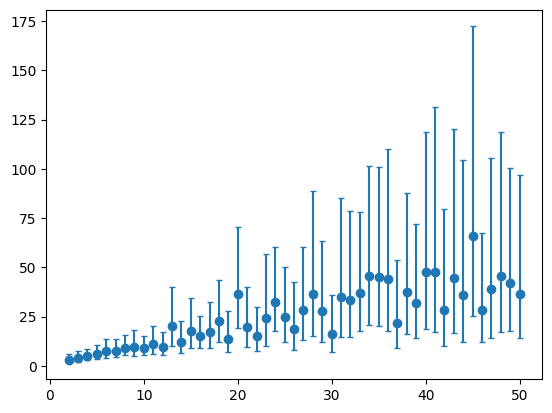

In [14]:
plt.errorbar(target, prediction, [y_error_lower, y_error_upper], fmt='o', capsize=2)

In [15]:
## MCMC predictions

In [16]:
mcmc_results = pd.read_csv("syn_data/mcmc_results.csv")

In [17]:
mcmc_median = mcmc_results["median"] / 1.15

In [18]:
mcmc_lower = mcmc_results["lower"] / 1.15
mcmc_upper = mcmc_results['uppder'] / 1.15

In [19]:
def simple_peak_snr_auto(ds, frac=0.3):
    ts = ds.mean(axis=0)
    n = ts.size
    m = int(frac * n)
    off = np.r_[0:m, n-m:n]
    mu = ts[off].mean()
    sigma = ts[off].std(ddof=1)
    snr = (ts.max() - mu) / sigma
    return snr

In [ ]:
snrs = []
for i in range(49):
    ds = np.load(f"synthetic_burst_{i}.npy")
    snr = simple_peak_snr_auto(ds)
    snrs.append(snr)

In [21]:
snrs 

[20.806007171281077,
 18.414435919139066,
 13.915123466398684,
 14.258942969243142,
 11.784102102722835,
 12.740589993822983,
 12.105215116041457,
 12.17783040589035,
 12.362458733463951,
 11.883530781874764,
 9.298883335751073,
 7.1062497932622275,
 8.453074441764171,
 7.676475337887193,
 7.917374434573567,
 7.407249901699712,
 7.463275259794253,
 6.365687270024593,
 6.11760475500174,
 6.2200959937445734,
 8.0839285255924,
 5.534888117874572,
 7.309604396352421,
 6.786328200894548,
 5.017364162663101,
 5.500737498394381,
 4.9191577950192995,
 4.627852741829791,
 6.288928803531664,
 5.004137204319521,
 4.580310865148032,
 6.066131305061257,
 4.614009407386227,
 4.347777014215145,
 4.493976475985367,
 4.7654727253729865,
 4.79334403983133,
 5.20211634272797,
 4.002307098509653,
 4.872599519704496,
 3.6741076887740274,
 3.1357478650482653,
 3.0533869584743667,
 3.5138605548970063,
 4.6372667021208445,
 4.317906654919634,
 3.5933201759126083,
 5.221860269249971,
 4.23902784170593]

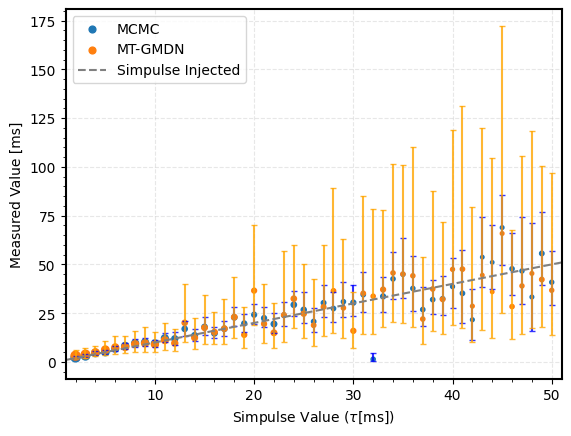

In [ ]:
plt.errorbar(target, mcmc_median, [mcmc_lower, mcmc_upper], fmt='none', capsize=2, color='blue', alpha=0.8)
plt.scatter(target, mcmc_median, s=np.array(snrs)*2, label="MCMC")
plt.errorbar(target, prediction, [y_error_lower, y_error_upper], fmt='none', color='orange', capsize=2, alpha=0.8)
plt.scatter(target, prediction, s=np.array(snrs)*2, label="MT-GMDN")
plt.plot(np.arange(0, 60), np.arange(0, 60), linestyle='--', c='gray', label="Simpulse Injected")
plt.xlim(1, 51)
plt.xlabel(r"Simpulse Value ($\tau$[ms])")
plt.ylabel(r"Measured Value [ms]")

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.5)
ax.minorticks_on()
ax.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.savefig("mcmc_vs_mtgmdn.jpg", dpi=600, bbox_inches="tight")

[2.7465013835741128,
 3.5218645178753403,
 3.5670578998068114,
 4.338011948958688,
 5.939316127611244,
 5.763358240542204,
 6.70735732368801,
 8.53088544762653,
 6.326924199643344,
 8.958494766898777,
 7.302241947339928,
 19.860488228175953,
 10.289805039115576,
 16.72668125318444,
 10.219910663107168,
 15.092924366826598,
 20.541390128757644,
 14.092279517132303,
 33.807024748429015,
 20.275747879691746,
 15.16892142917799,
 32.7116294529127,
 27.661733212678328,
 25.40270100469175,
 23.802049056343414,
 31.87071758767833,
 52.53969275433085,
 35.481804557468585,
 20.06595943285071,
 50.031389982804015,
 44.94609335194464,
 40.73765630307405,
 55.79351673955504,
 56.14911618440048,
 66.07913141665252,
 31.824291063391644,
 50.44660485309104,
 39.75078748620074,
 71.454729826554,
 83.8005298116933,
 50.75889255689539,
 75.62571981678839,
 68.52913566257644,
 106.40433933423914,
 39.129980336064875,
 66.52297641920006,
 73.22994066321331,
 58.183799411939546,
 59.95245560355809]

In [31]:
def summarize(y, pred, lower, upper, name="model"):
    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    r2 = r2_score(y, pred)
    bias = np.mean(pred - y)
    coverage = np.mean((y >= (pred - lower)) & (y <= (pred + upper)))
    width = np.mean(upper - lower)

    print(f"{name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)
    print("Bias:", bias)
    print("95% coverage:", coverage)
    print("Mean interval width:", width)
    print()

In [32]:
summarize(target, np.array(prediction), np.array(y_error_lower), np.array(y_error_upper), name="MT-GMDN")
summarize(target, np.array(mcmc_median), np.array(mcmc_lower), np.array(mcmc_upper), name="MCMC")

MT-GMDN
MAE: 5.495245320879471
RMSE: 7.619914350731808
R2: 0.7096845264375573
Bias: -0.0031905923147780403
95% coverage: 1.0
Mean interval width: 19.699277169109983

MCMC
MAE: 4.672097466007555
RMSE: 7.8258377516936415
R2: 0.693781317420833
Bias: -0.06843455784785252
95% coverage: 0.8979591836734694
Mean interval width: 2.496757619005246

